In [115]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

In [116]:

df_dict = {
    "Clock Time":["12:00", "14:00", "16:00", "18:00", "20:00", "22:00", "00:00", "02:00", "04:00", "06:00", "08:00", "10:00", "12:00"],
    "Circadian_Time": ["-10", "-8", "-6","-4", "-2", "0", "2", "4", "6", "8", "10", "12", "14"],
    "Melatonin_Value": [1.23, 1.21, 1.56, 1.23, 3.56, 19.33, 26.78, 28.22, 28.65, 20.61, 4.33, 3.23, 1.48],
    "Sleepiness_Z_Score": [-0.37, -0.22, -0.02, -0.45, -0.42, 0.17, 0.53, 0.88, 1.29, 0.99, 0.75, 0.66, 0.62],
    "Sleepiness_Lower": [-0.62, -0.47, -0.27, -0.71, -0.68, -0.08, 0.28, 0.62, 1.03, 0.74, 0.50, 0.41, 0.37],
    "Sleepiness_Upper": [-0.12, 0.03, 0.23, -0.19, -0.16, 0.42, 0.78, 1.14, 1.55, 1.24, 1.01, 0.91, 0.87]
}
df = pd.DataFrame(df_dict)
df

,Clock Time,Circadian_Time,Melatonin_Value,Sleepiness_Z_Score,Sleepiness_Lower,Sleepiness_Upper
0,12:00,-10,1.23,-0.37,-0.62,-0.12
1,14:00,-8,1.21,-0.22,-0.47,0.03
2,16:00,-6,1.56,-0.02,-0.27,0.23
3,18:00,-4,1.23,-0.45,-0.71,-0.19
4,20:00,-2,3.56,-0.42,-0.68,-0.16
5,22:00,0,19.33,0.17,-0.08,0.42
6,00:00,2,26.78,0.53,0.28,0.78
7,02:00,4,28.22,0.88,0.62,1.14
8,04:00,6,28.65,1.29,1.03,1.55
9,06:00,8,20.61,0.99,0.74,1.24


/var/folders/0g/z012d0sd26dc750zcz28ms7m0000gn/T/ipykernel_1738/2842530687.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(df["Circadian_Time"], rotation=45)


Text(-0.33, 0.8, '')

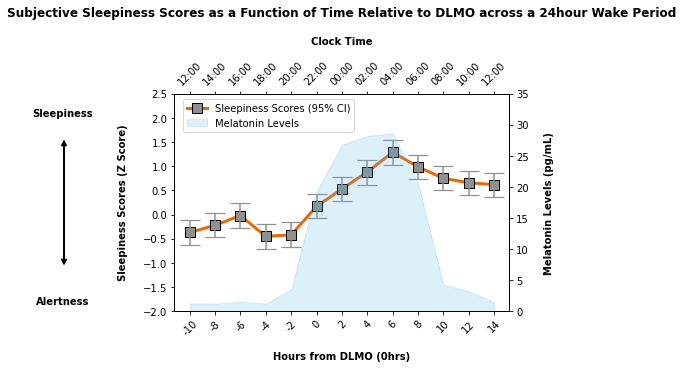

In [ ]:
fig, ax1 = plt.subplots()
ax2 = ax1.twinx()
ax3 = ax1.twiny()
ax2.fill_between(df["Circadian_Time"], df["Melatonin_Value"], color="#56B4E9", alpha=0.2, label="Melatonin Levels")
ax1.plot(df["Circadian_Time"], df["Sleepiness_Z_Score"], color="#E66808", marker="s", markerfacecolor = "#8F9190", 
         markeredgecolor= "#000000", markersize=10, linewidth=3, label="Sleepiness Scores (95% CI)")

# add confidence intervals
yerr = np.array([
    pd.to_numeric(df["Sleepiness_Z_Score"]) - pd.to_numeric(df["Sleepiness_Lower"]), 
    pd.to_numeric(df["Sleepiness_Upper"]) - pd.to_numeric(df["Sleepiness_Z_Score"]) 
])
x = df["Circadian_Time"]
ax1.errorbar(
    x, df["Sleepiness_Z_Score"],
    yerr=yerr,
    fmt='o', color="#8F9190", capsize=10, capthick=1.2)

# create title, labels, ticks
ax1.set_title("Subjective Sleepiness Scores as a Function of Time Relative to DLMO across a 24hour Wake Period", weight="bold", pad=20)
ax1.set_ylim(-2, 2.5)
ax1.set_xlabel("Hours from DLMO (0hrs)", weight="bold", labelpad=15)
ax1.set_xticklabels(df["Circadian_Time"], rotation=45)
ax1.set_ylabel("Sleepiness Scores (Z Score)", weight="bold", labelpad=15)

ax2.set_ylim(0, 35)
ax2.set_ylabel("Melatonin Levels (pg/mL)", weight="bold", labelpad=15)

ax3.set_xlim(ax1.get_xlim())
ax3.set_xticks(ax1.get_xticks())
ax3.set_xticklabels(df["Clock Time"], rotation=45 )
ax3.set_xlabel("Clock Time", weight="bold", labelpad=15)

#create legend for both axes
h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, loc="upper left", bbox_to_anchor=(0.01, 0.999))

# anotations - this creates the bidirectional arrow between sleepiness and alertness                                                                                                                                                                                         
# The purpose of this annotation is to indicate increased scores reflect sleepiness and decreased scores reflect alertness                                                                                                                            

ax1.text(-5,2, "Sleepiness", size=10, ha="center", va="bottom", weight="bold")
ax1.text(-5,-1.7, "Alertness", size=10, ha="center", va="top", weight="bold")
ax1.annotate("", xy=(-0.33, 0.2), xytext=(-0.33, 0.8),
             xycoords="axes fraction", textcoords="axes fraction",
             arrowprops=dict(arrowstyle="<->", lw=2), clip_on=False)